# Analisis Tugas: Model Explainability dengan skforecast

Berikut adalah jawaban dari pertanyaan yang diberikan, berdasarkan analisis dari panduan *skforecast explainability*:

### 1. Analisa prediksi tentang apa?
Analisa ini bertujuan untuk **memprediksi tingkat permintaan listrik (electricity demand)** di wilayah Victoria, Australia. Data yang awalnya dicatat setiap setengah jam diagregasi (digabungkan) menjadi frekuensi **harian**. Jadi, model ini memprediksi total permintaan listrik harian di wilayah tersebut.

### 2. Bagaimana bentuk data trainingnya (apa saja inputnya dan apa outputnya)?
Bentuk data *training*-nya berupa matriks baris dan kolom (seperti tabel dua dimensi) yang dibentuk dari data deret waktu (*time series*).
*   **Input (Fitur/X):**
    *   **Nilai *Lag* (historis):** Permintaan listrik dari 7 hari sebelumnya (`lag_1`, `lag_2`, `lag_3`, `lag_4`, `lag_5`, `lag_6`, dan `lag_7`).
    *   **Variabel Eksogen (tambahan):** Rata-rata `Temperature` (Suhu) harian.
*   **Output (Target/y):**
    *   Total permintaan listrik (`Demand`) pada hari target yang ingin diprediksi.

### 3. Apa itu *lag*?
**Lag** adalah nilai observasi dari waktu sebelumnya yang digunakan sebagai variabel prediksi (input) untuk memprediksi kondisi waktu saat ini atau di masa depan. 
Sebagai contoh, jika kita memprediksi permintaan listrik untuk hari ini, `lag_1` adalah permintaan listrik tepat 1 hari yang lalu (kemarin), `lag_2` adalah 2 hari yang lalu, dan seterusnya. Dalam kasus ini, kita menggunakan *lag* hingga 7 hari ke belakang untuk menangkap pola mingguan.

### 4. Jelaskan proses analysis yang dilakukan dari kasus di atas
Proses analisis yang dilakukan terdiri dari beberapa tahapan utama:
1. **Persiapan Data (Data Preparation):** Data permintaan listrik yang awalnya dicatat per 30 menit diubah (*resampling*) menjadi data harian (dengan menjumlahkan permintaan dan merata-rata suhu). Kemudian, data dipisah menjadi dua bagian: *data latih* (train data) hingga 21 Desember 2014, dan *data uji* (test data) dari 22 Desember 2014 dan seterusnya.
2. **Pembuatan & Pelatihan Model (Modeling):** Model regresi prediksi (*ForecasterRecursive*) dibuat menggunakan algoritma **LightGBM**. Model ini dilatih untuk memprediksi permintaan listrik berdasarkan *lags* (7 hari terakhir) dan fitur suhu (*Temperature*).
3. **Analisis *Feature Importance*:** Mengecek variabel mana yang secara umum paling penting untuk model dalam membuat keputusan prediksi (menggunakan atribut bawaan dari algoritma pohon keputusan).
4. **Analisis SHAP (SHapley Additive exPlanations):** Menggunakan teknik SHAP (dalam hal ini `TreeExplainer`) untuk mendapatkan penjelasan yang sangat mendetail mengenai seberapa besar setiap variabel (seperti suhu atau `lag_1`) mendorong nilai prediksi naik atau turun pada setiap harinya. Analisis ini divisualisasikan dengan **Summary Plot** dan **Dependence Plot**.
5. **Permutation Feature Importance:** Menganalisis seberapa penting suatu fitur dengan cara mengacak (shuffle) nilai dari fitur tersebut. Jika setelah diacak prediksi model menjadi sangat buruk, berarti model sangat bergantung dan fitur tersebut sangat penting.
6. **Partial Dependence Plots (PDP):** Memvisualisasikan rata-rata efek atau hubungan langsung antara suatu fitur tertentu (misal: suhu) terhadap hasil prediksi model, dengan mengabaikan efek fitur lainnya.

---
Berikut adalah reproduksi *code* lengkap (beserta penjelasan tambahan per langkah) yang bisa dijalankan di Localhost maupun Google Colab.


### Instalasi Library (Penting untuk Colab)

In [1]:
!pip install skforecast lightgbm shap matplotlib scikit-learn pandas


   ---------------------------------------- 0.0/467.3 kB ? eta -:--:--
   -------- ------------------------------- 102.4/467.3 kB 5.8 MB/s eta 0:00:01
   ------------------------ --------------- 286.7/467.3 kB 4.4 MB/s eta 0:00:01
   ---------------------------------------- 467.3/467.3 kB 4.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -------- ------------------------------- 0.3/1.5 MB 6.3 MB/s eta 0:00:01
   --------------- ------------------------ 0.6/1.5 MB 7.1 MB/s eta 0:00:01
   ------------------- -------------------- 0.7/1.5 MB 6.2 MB/s eta 0:00:01
   ------------------- -------------------- 0.7/1.5 MB 6.2 MB/s eta 0:00:01
   ------------------- -------------------- 0.7/1.5 MB 6.2 MB/s eta 0:00:01
   --------------------------------- ------ 1.2/1.5 MB 4.8 MB/s eta 0:00:01
   -------------------------------------- - 1.4/1.5 MB 4.9 MB/s eta 0:00:01
   ---------------------------------------  1.4/1.5 MB 4.4 MB/s eta 0:00:01
   ---------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### 1. Mengimpor Library & Dataset

In [2]:
# Mengimpor library yang dibutuhkan
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from lightgbm import LGBMRegressor
from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive

# Konfigurasi plot agar lebih rapi
plt.style.use('seaborn-v0_8-darkgrid')


In [3]:
# Mendownload dataset (Data Victoria Electricity Demand)
data = fetch_dataset(name="vic_electricity")
print("Bentuk dataset asli:", data.shape)
display(data.head(3))


╭──────────────────────────── vic_electricity ─────────────────────────────╮
│ Description:                                                             │
│ Half-hourly electricity demand for Victoria, Australia                   │
│                                                                          │
│ Source:                                                                  │
│ O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse │
│ Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,              │
│ https://github.com/tidyverts/tsibbledata/.                               │
│ https://tsibbledata.tidyverts.org/reference/vic_elec.html                │
│                                                                          │
│ URL:                                                                     │
│ https://raw.githubusercontent.com/skforecast/skforecast-                 │
│ datasets/main/data/vic_electricity.csv                                   │
│                                                                          │
│ Shape: 52608 rows x 4 columns                                            │
╰──────────────────────────────────────────────────────────────────────────╯

Bentuk dataset asli: (52608, 4)


,Demand,Temperature,Date,Holiday
Time,,,,
2011-12-31 13:00:00,4382.825174,21.40,2012-01-01,True
2011-12-31 13:30:00,4263.365526,21.05,2012-01-01,True
2011-12-31 14:00:00,4048.966046,20.70,2012-01-01,True


### 2. Pra-pemrosesan Data (Agregasi)

In [4]:
# Agregasi data dari per 30 menit menjadi frekuensi harian (Daily)
# Permintaan di-sum (jumlah total harian), Suhu di-mean (rata-rata harian)
data = data.resample('D').agg({'Demand': 'sum', 'Temperature': 'mean'})
print("Bentuk dataset setelah agregasi harian:", data.shape)
display(data.head(3))


Bentuk dataset setelah agregasi harian: (1097, 2)


,Demand,Temperature
Time,,
2011-12-31,82531.745918,21.047727
2012-01-01,227778.257304,26.578125
2012-01-02,275490.988882,31.751042


In [5]:
# Membagi data menjadi data latih (train) dan data uji (test)
data_train = data.loc[: '2014-12-21']
data_test = data.loc['2014-12-22':]

print(f"Data latih: {data_train.index.min()} sampai {data_train.index.max()}")
print(f"Data uji: {data_test.index.min()} sampai {data_test.index.max()}")


Data latih: 2011-12-31 00:00:00 sampai 2014-12-21 00:00:00
Data uji: 2014-12-22 00:00:00 sampai 2014-12-31 00:00:00


### 3. Pembuatan dan Pelatihan Forecaster

In [8]:
# Membuat model peramalan rekursif multi-step
# Menggunakan model LightGBM dengan lag 7 hari ke belakang
forecaster = ForecasterRecursive(
                 estimator = LGBMRegressor(random_state=123, verbose=-1),
                 lags      = 7
             )

# Melatih model (Training) menggunakan data latih
forecaster.fit(
    y    = data_train['Demand'],
    exog = data_train['Temperature']
)
forecaster


=================== 
ForecasterRecursive 
=================== 
Estimator: LGBMRegressor 
Lags: [1 2 3 4 5 6 7] 
Window features: None 
Window size: 7 
Series name: Demand 
Exogenous included: True 
Exogenous names: Temperature 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: [Timestamp('2011-12-31 00:00:00'), Timestamp('2014-12-21 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Day> 
Estimator parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 123, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0,
    'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-06-11 13:41:29 
Last fit date: 2026-06-11 13:41:31 
Skforecast version: 0.22.0 
Python version: 3.12.4 
Forecaster id: None

### 4. Evaluasi Pentingnya Fitur (Feature Importance)

In [9]:
# 1. Mengecek pentingnya fitur (Feature Importance) secara umum dari model bawaan
forecaster.get_feature_importances()


,feature,importance
7,Temperature,570
0,lag_1,470
2,lag_3,387
1,lag_2,362
6,lag_7,325
5,lag_6,313
4,lag_5,298
3,lag_4,275


In [10]:
# 2. Melihat bentuk matriks data latih (Input X dan Output y)
# Inilah yang dimaksud bentuk data training, model mengubah deret waktu menjadi matriks standar
X_train, y_train = forecaster.create_train_X_y(
                       y    = data_train['Demand'],
                       exog = data_train['Temperature']
                   )

print("--- INPUT (X_train) ---")
display(X_train.head(3))

print("\n--- OUTPUT (y_train) ---")
display(y_train.head(3))


--- INPUT (X_train) ---


,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
Time,,,,,,,,
2012-01-07,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,82531.745918,24.098958
2012-01-08,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,20.223958
2012-01-09,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,19.161458



--- OUTPUT (y_train) ---


Time
2012-01-07    200693.270298
2012-01-08    200061.614738
2012-01-09    216201.836844
Freq: D, Name: y, dtype: float64

### 5. Penjelasan Model dengan SHAP Values

In [11]:
# 3. Analisis dengan SHAP Values
shap.initjs() # Agar visualisasi interaktif SHAP muncul (terutama di Jupyter Notebook)

# Membuat explainer khusus model berbasis pohon (LightGBM)
explainer = shap.TreeExplainer(forecaster.estimator)

# Menghitung nilai SHAP untuk data latih
shap_values = explainer.shap_values(X_train)


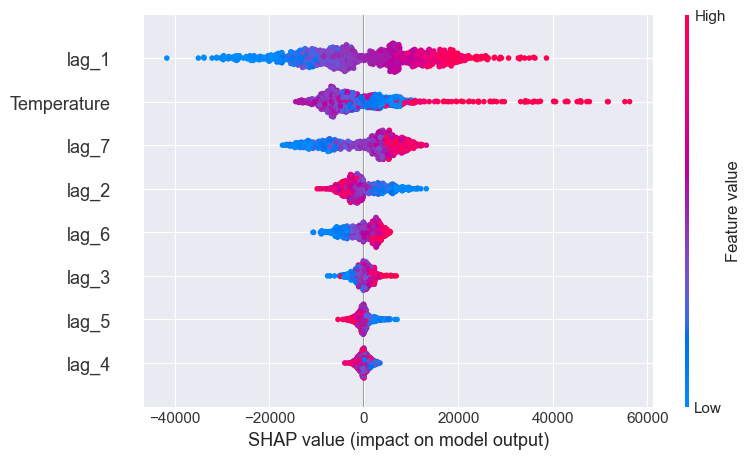

In [12]:
# Membuat SHAP Summary Plot
# Menunjukkan bagaimana masing-masing fitur berdampak pada output prediksi (naik/turun)
shap.summary_plot(shap_values, X_train)


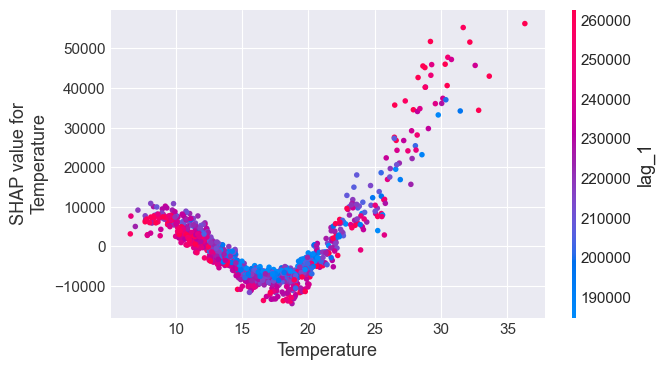

In [13]:
# Membuat SHAP Dependence Plot untuk Suhu (Temperature)
# Melihat hubungan spesifik antara suhu dan efeknya pada prediksi permintaan listrik
fig, ax = plt.subplots(figsize=(7, 4))
shap.dependence_plot("Temperature", shap_values, X_train, ax=ax)


### 6. Melakukan Prediksi (Forecasting)

In [14]:
# Melakukan Prediksi untuk 10 hari ke depan
predictions = forecaster.predict(steps=10, exog=data_test['Temperature'])
display(predictions)


2014-12-22    241514.532543
2014-12-23    226165.936559
2014-12-24    220506.468700
2014-12-25    209260.948991
2014-12-26    184885.145832
2014-12-27    195623.591810
2014-12-28    222766.340659
2014-12-29    223112.716406
2014-12-30    219103.891733
2014-12-31    217948.965404
Freq: D, Name: pred, dtype: float64

### 7. Permutation Feature Importance & Partial Dependence Plot

In [15]:
# 4. Permutation Feature Importance
# Mengukur seberapa penting sebuah fitur dengan cara mengacak nilainya
r = permutation_importance(
        estimator    = forecaster.estimator,
        X            = X_train,
        y            = y_train,
        n_repeats    = 3,
        max_samples  = 0.5,
        random_state = 123
    )

importances = pd.DataFrame({
                  'feature': X_train.columns,
                  'mean_importance': r.importances_mean,
                  'std_importance': r.importances_std
              }).sort_values('mean_importance', ascending=False)
display(importances)


,feature,mean_importance,std_importance
0,lag_1,0.617276,0.014583
7,Temperature,0.411240,0.014405
6,lag_7,0.196190,0.001865
1,lag_2,0.122398,0.007803
5,lag_6,0.083912,0.003637
2,lag_3,0.041294,0.002019
4,lag_5,0.030787,0.001079
3,lag_4,0.024816,0.001021


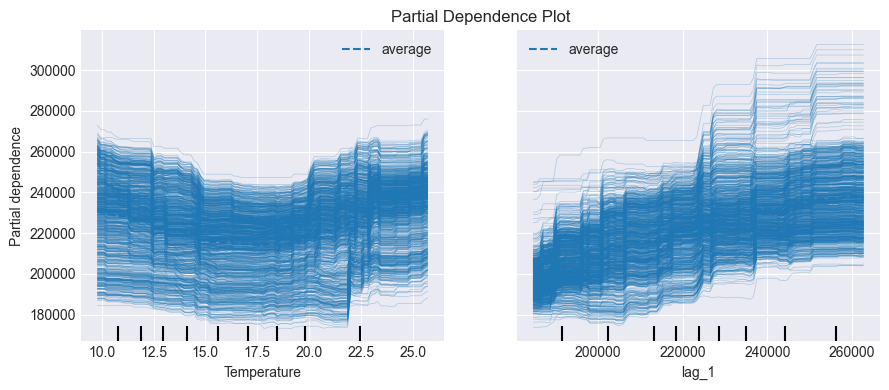

In [16]:
# 5. Scikit-learn Partial Dependence Plots (PDP)
# Menunjukkan rata-rata efek marjinal fitur pada target prediksi
fig, ax = plt.subplots(figsize=(9, 4))
ax.set_title("Decision Tree")
pd.plots = PartialDependenceDisplay.from_estimator(
    estimator = forecaster.estimator,
    X         = X_train,
    features  = ["Temperature", "lag_1"],
    kind      = 'both',
    ax        = ax,
)
ax.set_title("Partial Dependence Plot")
fig.tight_layout()
